In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt

from union21_mcmc.Cosmology import distance_modulus

from union21_mcmc.data import (
    load_union21_data,
    load_union21_covariance
)

from union21_mcmc.Bayes import (
    log_prior,
    log_posterior,
    log_likelihood,
    cholesky_covariance
)

from union21_mcmc.MCMC import (
    run_chains,
    metropolis_hastings
)

from union21_mcmc.diagnostics import (
    autocorrelation,
    split_rhat,
    integrated_autocorrelation_time,
    effective_sample_size,
    power_spectrum,
    dunkley_power_spectrum
)

from union21_mcmc.plots import (
    plot_traces,
    plot_acceptance_rates,
    plot_autocorrelation,
    plot_corner,
    plot_power_spectrum,
    plot_hubble_diagram
)

In [24]:
RESULTS_DIR = "results"

N_CHAINS = 5
N_SAMPLES = 50000
BURN_IN = 10000

PILOT_SAMPLES = 10000
PILOT_BURN_IN = 2000

H_0 = 70.0

PARAMETER_NAMES = ["Omega_M","Omega_DE"]

OMEGA_M_INDEX = 0
OMEGA_DE_INDEX = 1
ndim = 2
z, mu_obs = load_union21_data()
C = load_union21_covariance()
L = cholesky_covariance(C)

theta_initials = np.array([
    [0.20, 0.80],
    [0.25, 0.70],
    [0.30, 0.60],
    [0.35, 0.75],
    [0.40, 0.65]
])


# Proposal covariance
proposal_cov_initial = np.diag([
    0.05**2,
    0.10**2
])

# Pilot MCMC

print("\nRunning pilot MCMC...")

pilot_samples, pilot_acceptance = metropolis_hastings(
    log_posterior=log_posterior,
    initial_state=theta_initials[0],
    num_samples=PILOT_SAMPLES,
    proposal_cov=proposal_cov_initial,
    C=L,
    z=z,
    mu_obs=mu_obs,
    rng=np.random.default_rng(123)
)

pilot_cov = np.cov(
    pilot_samples[PILOT_BURN_IN:].T
)

print(
    f"Pilot acceptance rate: "
    f"{pilot_acceptance:.4f}"
)

# Estimate proposal covariance
pilot_cov = np.cov(pilot_samples[2000:].T)
proposal_cov = ((2.38**2 / ndim) * pilot_cov)

print("\nPilot covariance:")
print(pilot_cov)

print("\nFinal proposal covariance:")
print(proposal_cov)

# Check configuration
if len(theta_initials) != N_CHAINS:
    raise ValueError(
        "The number of initial states must match N_CHAINS."
    )

# Create results directory

os.makedirs(RESULTS_DIR,exist_ok=True)

print(f"Number of supernovae: {len(z)}")
print(
    f"Redshift range: "
    f"{np.min(z):.4f} - {np.max(z):.4f}")

print(f"Covariance shape: {C.shape}")

# Check data and covariance dimensions

if C.shape != (len(z), len(z)):
    raise ValueError(
        "Covariance matrix dimensions do not match "
        "the number of supernovae."
    )

print("\nRunning MCMC...")
print(f"Number of chains: {N_CHAINS}")
print(f"Samples per chain: {N_SAMPLES}")

chains, acceptance_rates = run_chains(
    log_posterior,
    theta_initials,
    N_SAMPLES,
    proposal_cov,
    L,
    z,
    mu_obs,
    seed=42
)

# Check chain shape
expected_shape = (N_CHAINS,N_SAMPLES,len(PARAMETER_NAMES))

if chains.shape != expected_shape:
    raise ValueError(
        f"Unexpected chain shape: {chains.shape}. "
        f"Expected: {expected_shape}"
    )

# Acceptance rates
print("\nAcceptance rates:")
print("-" * 40)

for i, rate in enumerate(acceptance_rates):

    print(
        f"Chain {i + 1}: "
        f"{rate:.4f}"
    )

# Remove burn-in
if BURN_IN >= N_SAMPLES:
    raise ValueError("BURN_IN must be smaller than N_SAMPLES.")


print("\nRemoving burn-in...")
chains_post = chains[:,BURN_IN:,:]

print(
    f"Posterior chains shape: "
    f"{chains_post.shape}")

# Extract Omega_M and Omega_DE
omega_m_chains = chains_post[:,:,OMEGA_M_INDEX]
omega_de_chains = chains_post[:,:,OMEGA_DE_INDEX]



Running pilot MCMC...
Acceptance Rate: 63.56%
Pilot acceptance rate: 0.6356

Pilot covariance:
[[0.01321851 0.02063937]
 [0.02063937 0.04653996]]

Final proposal covariance:
[[0.03743747 0.05845482]
 [0.05845482 0.13181046]]
Number of supernovae: 580
Redshift range: 0.0150 - 1.4140
Covariance shape: (580, 580)

Running MCMC...
Number of chains: 5
Samples per chain: 50000
Running chain 1/5
Acceptance Rate: 34.23%
Running chain 2/5
Acceptance Rate: 34.31%
Running chain 3/5
Acceptance Rate: 34.37%
Running chain 4/5
Acceptance Rate: 34.33%
Running chain 5/5
Acceptance Rate: 34.31%

Acceptance rates:
----------------------------------------
Chain 1: 0.3423
Chain 2: 0.3431
Chain 3: 0.3437
Chain 4: 0.3433
Chain 5: 0.3431

Removing burn-in...
Posterior chains shape: (5, 40000, 2)


In [21]:
# Convergence diagnostics
print("\nConvergence diagnostics")
print("=" * 50)

# Omega_M
rhat_omega_m = split_rhat(omega_m_chains)

print(
    f"Omega_M R-hat  = "
    f"{rhat_omega_m:.6f}"
)

# Omega_DE
rhat_omega_de = split_rhat(omega_de_chains)

print(
    f"Omega_DE R-hat = "
    f"{rhat_omega_de:.6f}"
)


print("\nAutocorrelation diagnostics")
print("=" * 50)

# Omega_M
tau_omega_m = []
ess_omega_m = []
mcse_omega_m = []

for chain in omega_m_chains:

    acf = autocorrelation(chain)
    tau = integrated_autocorrelation_time(acf)
    ess = effective_sample_size(len(chain), tau)

    tau_omega_m.append(tau)
    ess_omega_m.append(ess)

    mcse_omega_m.append(
        np.std(chain, ddof=1) / np.sqrt(ess)
    )

tau_omega_m = np.asarray(tau_omega_m)
ess_omega_m = np.asarray(ess_omega_m)
mcse_omega_m = np.asarray(mcse_omega_m)

print("\nOmega_M")
print(f"IAT per chain: {tau_omega_m}")
print(f"ESS per chain: {ess_omega_m}")
print(f"Total ESS: {np.sum(ess_omega_m):.1f}")
print(f"MCSE per chain: {mcse_omega_m}")

# Omega_DE
tau_omega_de = []
ess_omega_de = []
mcse_omega_de = []

for chain in omega_de_chains:

    acf = autocorrelation(chain)
    tau = integrated_autocorrelation_time(acf)
    ess = effective_sample_size(len(chain), tau)

    tau_omega_de.append(tau)
    ess_omega_de.append(ess)

    mcse_omega_de.append(
        np.std(chain, ddof=1) / np.sqrt(ess)
    )

tau_omega_de = np.asarray(tau_omega_de)
ess_omega_de = np.asarray(ess_omega_de)
mcse_omega_de = np.asarray(mcse_omega_de)

print("\nOmega_DE")
print(f"IAT per chain: {tau_omega_de}")
print(f"ESS per chain: {ess_omega_de}")
print(f"Total ESS: {np.sum(ess_omega_de):.1f}")
print(f"MCSE per chain: {mcse_omega_de}")

# Posterior means and standard deviations
print("\nPosterior parameters")
print("=" * 50)

posterior_mean = np.mean(chains_post,axis=(0, 1))
posterior_std = np.std(chains_post,axis=(0, 1),ddof=1)

for name, mean, std in zip(
    PARAMETER_NAMES,
    posterior_mean,
    posterior_std
):

    print(
        f"{name:10s} = "
        f"{mean:.6f} +/- {std:.6f}"
    )

# Derived Omega_K
omega_k_chains = (
    1.0
    - chains_post[
        :,
        :,
        OMEGA_M_INDEX
    ]
    - chains_post[
        :,
        :,
        OMEGA_DE_INDEX
    ]
)

omega_k_mean = np.mean(
    omega_k_chains
)

omega_k_std = np.std(
    omega_k_chains,
    ddof=1
)

omega_m_mean = np.mean(
    chains_post[:, :, OMEGA_M_INDEX]
)

omega_de_mean = np.mean(
    chains_post[:, :, OMEGA_DE_INDEX]
)

print(
    f"{'Omega_K':10s} = "
    f"{omega_k_mean:.6f} +/- "
    f"{omega_k_std:.6f}"
)

model_mu = distance_modulus(
    z,
    H_0,
    omega_m_mean,
    omega_de_mean
)

sigma_mu = np.sqrt(np.diag(C))


Convergence diagnostics
Omega_M R-hat  = 1.000142
Omega_DE R-hat = 1.000144

Autocorrelation diagnostics

Omega_M
IAT per chain: [7.11435024 7.93668356 7.1675397  8.63569334 8.13570944]
ESS per chain: [5622.4389646  5039.88847738 5580.71551717 4631.93844485 4916.59643317]
Total ESS: 25791.6
MCSE per chain: [0.001491   0.00159876 0.00147616 0.00162566 0.0016035 ]

Omega_DE
IAT per chain: [7.45492278 7.90327656 7.65714579 8.9329996  7.75905366]
ESS per chain: [5365.58207266 5061.19199041 5223.87859278 4477.77922318 5155.26786559]
Total ESS: 25283.7
MCSE per chain: [0.00285197 0.00297195 0.0028819  0.00311322 0.00293821]

Posterior parameters
Omega_M    = 0.280999 +/- 0.111745
Omega_DE   = 0.661724 +/- 0.209602
Omega_K    = 0.057277 +/- 0.309500


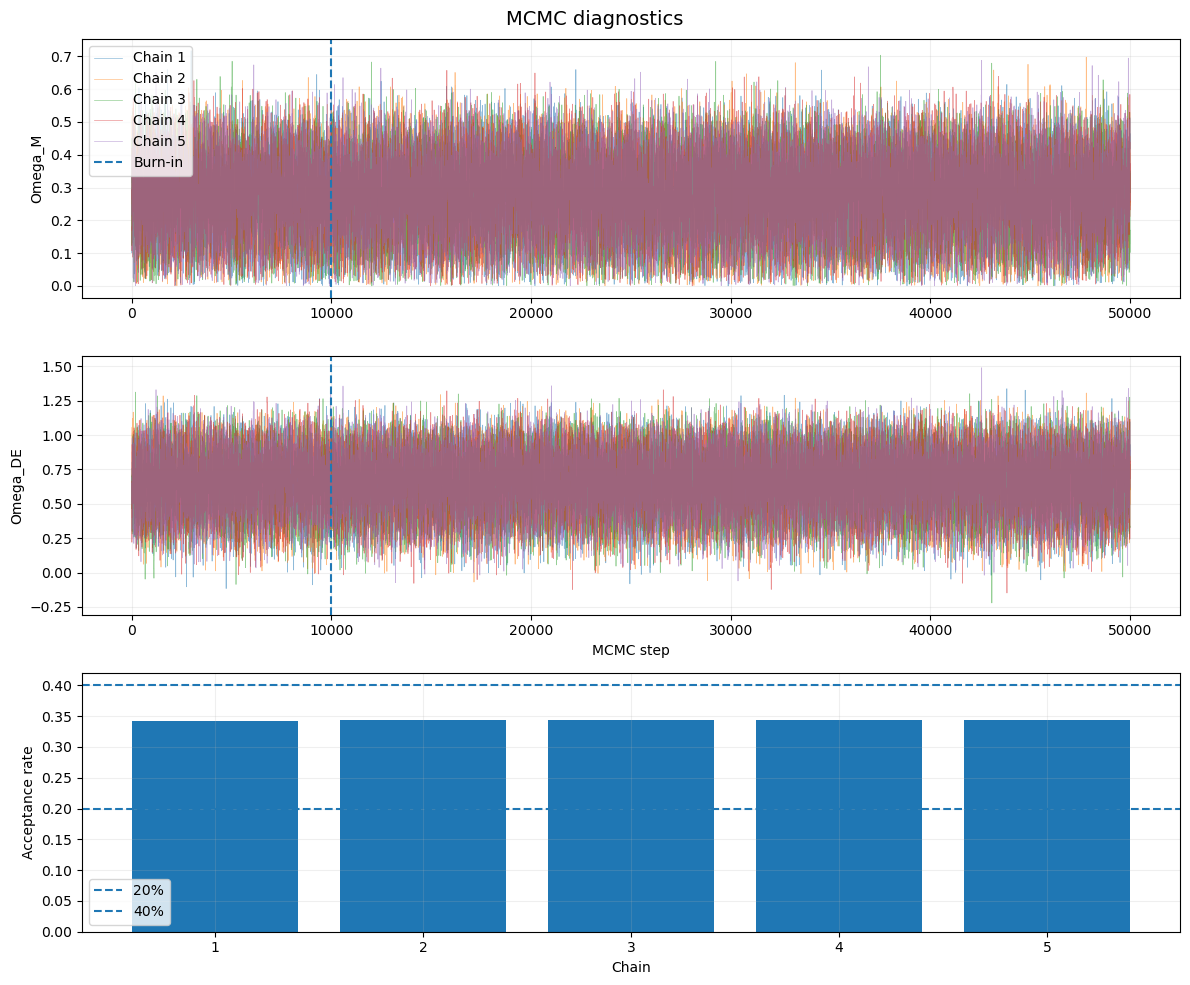

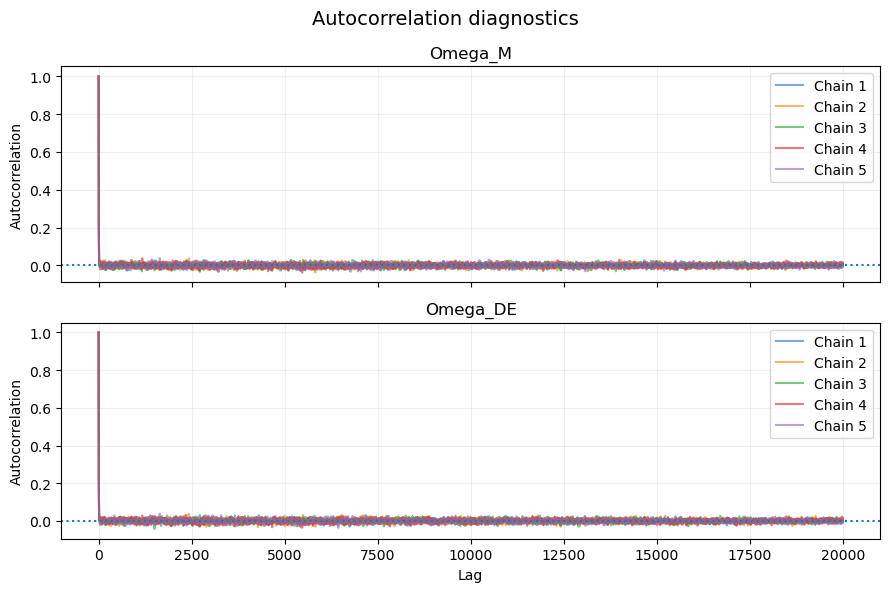

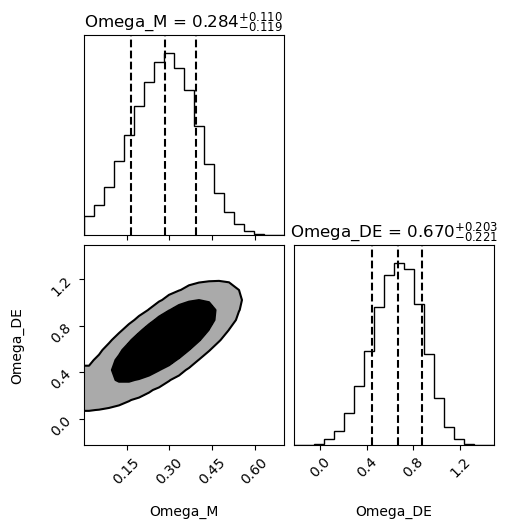


Power spectrum diagnostics

Chain 1
Omega_M: power spectrum calculated
Omega_DE: power spectrum calculated

Chain 2
Omega_M: power spectrum calculated
Omega_DE: power spectrum calculated

Chain 3
Omega_M: power spectrum calculated
Omega_DE: power spectrum calculated

Chain 4
Omega_M: power spectrum calculated
Omega_DE: power spectrum calculated

Chain 5
Omega_M: power spectrum calculated
Omega_DE: power spectrum calculated


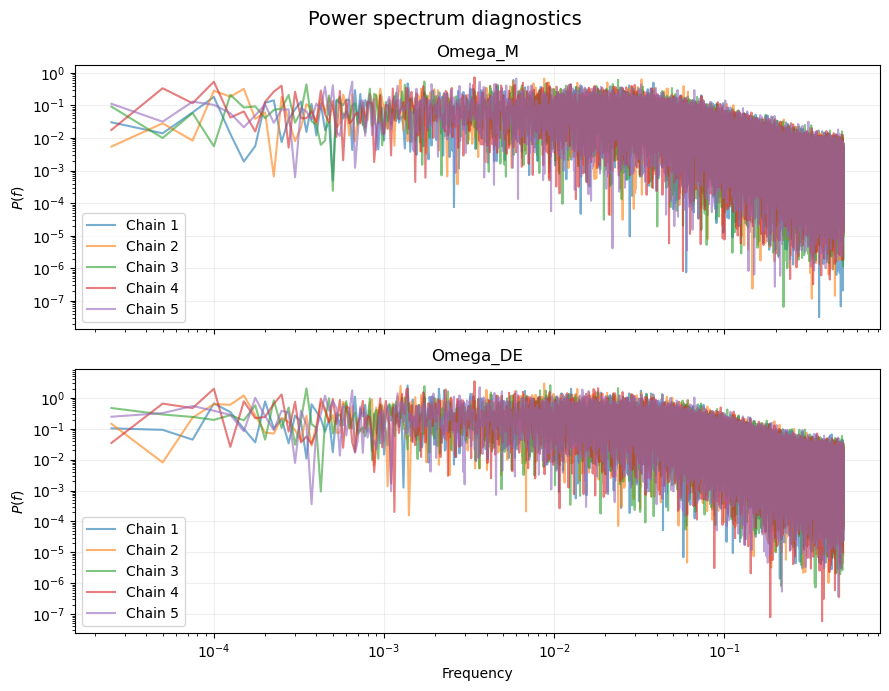

Power spectrum plots saved to: results/

Dunkley convergence diagnostics

Chain 1
Omega_M: P_0 = 3.021395e-02, j* = 4000.00, alpha = 2.00, r = 0.000060, passed = True
Omega_DE: P_0 = 1.033262e-01, j* = 4000.00, alpha = 2.00, r = 0.000059, passed = True

Chain 2
Omega_M: P_0 = 5.437832e-03, j* = 4000.00, alpha = 2.00, r = 0.000011, passed = True
Omega_DE: P_0 = 1.453367e-01, j* = 4000.00, alpha = 2.00, r = 0.000081, passed = True

Chain 3
Omega_M: P_0 = 9.149678e-02, j* = 4000.00, alpha = 2.00, r = 0.000188, passed = True
Omega_DE: P_0 = 4.701610e-01, j* = 4000.00, alpha = 2.00, r = 0.000271, passed = True

Chain 4
Omega_M: P_0 = 1.760836e-02, j* = 4000.00, alpha = 2.00, r = 0.000036, passed = True
Omega_DE: P_0 = 3.477909e-02, j* = 4000.00, alpha = 2.00, r = 0.000020, passed = True

Chain 5
Omega_M: P_0 = 1.119219e-01, j* = 4000.00, alpha = 2.00, r = 0.000221, passed = True
Omega_DE: P_0 = 2.457706e-01, j* = 4000.00, alpha = 2.00, r = 0.000138, passed = True


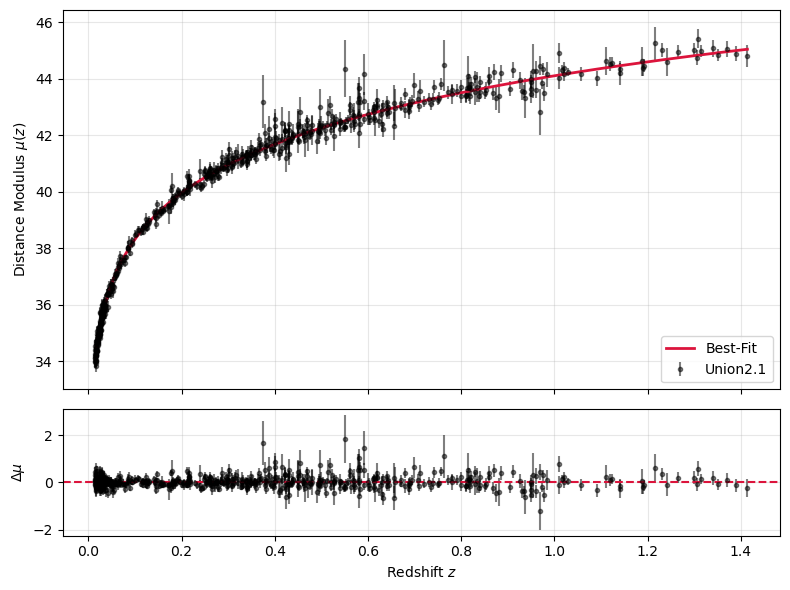


Analysis completed.
Results saved in: results/


In [22]:
# MCMC diagnostics plots

# Trace plots and acceptance rates
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 10)
)

for parameter_index, parameter_name in enumerate(PARAMETER_NAMES):
    for chain_index in range(N_CHAINS):

        axes[parameter_index].plot(
            chains[chain_index, :, parameter_index],
            lw=0.5,
            alpha=0.5,
            label=(
                f"Chain {chain_index + 1}"
                if parameter_index == 0
                else None
            )
        )

    if BURN_IN > 0:

        axes[parameter_index].axvline(
            BURN_IN,
            linestyle="--",
            label=(
                "Burn-in"
                if parameter_index == 0
                else None
            )
        )

    axes[parameter_index].set_ylabel(
        parameter_name
    )

    axes[parameter_index].grid(
        alpha=0.2
    )

axes[0].legend()
axes[1].set_xlabel("MCMC step")

# Acceptance rates
chain_numbers = np.arange(
    1,
    len(acceptance_rates) + 1
)

axes[2].bar(
    chain_numbers,
    acceptance_rates
)

axes[2].axhline(
    0.20,
    linestyle="--",
    label="20%"
)

axes[2].axhline(
    0.40,
    linestyle="--",
    label="40%"
)

axes[2].set_xlabel("Chain")
axes[2].set_ylabel("Acceptance rate")

axes[2].set_xticks(
    chain_numbers
)

axes[2].legend()
axes[2].grid(
    alpha=0.2
)

fig.suptitle(
    "MCMC diagnostics",
    fontsize=14
)

fig.tight_layout()

fig.savefig(
    os.path.join(
        RESULTS_DIR,
        "mcmc_diagnostics.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Autocorrelation diagnostics
fig, axes = plt.subplots(
    len(PARAMETER_NAMES),
    1,
    figsize=(9, 6),
    sharex=True
)

if len(PARAMETER_NAMES) == 1:
    axes = [axes]

for parameter_index, parameter_name in enumerate(PARAMETER_NAMES):
    for chain_index in range(N_CHAINS):

        chain = chains_post[
            chain_index,
            :,
            parameter_index
        ]

        acf = autocorrelation(chain)

        axes[parameter_index].plot(
            np.arange(len(acf)),
            acf,
            alpha=0.6,
            label=f"Chain {chain_index + 1}"
        )

    axes[parameter_index].axhline(
        0.0,
        linestyle=":"
    )

    axes[parameter_index].set_ylabel(
        "Autocorrelation"
    )

    axes[parameter_index].set_title(
        parameter_name
    )

    axes[parameter_index].grid(
        alpha=0.2
    )

    axes[parameter_index].legend()

axes[-1].set_xlabel("Lag")

fig.suptitle("Autocorrelation diagnostics",fontsize=14)
fig.tight_layout()

fig.savefig(
    os.path.join(
        RESULTS_DIR,
        "autocorrelation_diagnostics.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Corner plot
posterior_samples = chains_post.reshape(
    -1,
    len(PARAMETER_NAMES)
)

fig = plot_corner(
    samples=posterior_samples,
    param_names=PARAMETER_NAMES,
    save_path=os.path.join(
        RESULTS_DIR,
        "corner_plot.png"
    )
)

plt.show()

# Power spectrum diagnostics
print("\nPower spectrum diagnostics")
print("=" * 50)
power_spectra = {}
for chain_index in range(N_CHAINS):

    chain = chains_post[chain_index]

    power_spectra[chain_index] = {}

    print(f"\nChain {chain_index + 1}")

    for parameter_index, parameter_name in enumerate(
        PARAMETER_NAMES
    ):

        frequency, power = power_spectrum(
            chain[:, parameter_index]
        )

        power_spectra[
            chain_index
        ][parameter_index] = (
            frequency,
            power
        )

        np.savetxt(
            os.path.join(
                RESULTS_DIR,
                (
                    f"power_spectrum_chain_"
                    f"{chain_index + 1}_"
                    f"{parameter_name}.txt"
                )
            ),
            np.column_stack(
                [frequency, power]
            ),
            header="frequency power"
        )

        print(
            f"{parameter_name}: "
            f"power spectrum calculated"
        )

# Power spectrum plots
fig, axes = plt.subplots(
    len(PARAMETER_NAMES),
    1,
    figsize=(9, 7),
    sharex=True
)

if len(PARAMETER_NAMES) == 1:
    axes = [axes]


for parameter_index, parameter_name in enumerate(PARAMETER_NAMES):
    for chain_index in range(N_CHAINS):

        frequency, power = power_spectra[
            chain_index
        ][parameter_index]

        axes[parameter_index].loglog(
            frequency,
            power,
            alpha=0.6,
            label=f"Chain {chain_index + 1}"
        )

    axes[parameter_index].set_ylabel(
        r"$P(f)$"
    )

    axes[parameter_index].set_title(
        parameter_name
    )

    axes[parameter_index].grid(
        alpha=0.2
    )

    axes[parameter_index].legend()

axes[-1].set_xlabel("Frequency")
fig.suptitle("Power spectrum diagnostics",fontsize=14)

fig.tight_layout()

fig.savefig(
    os.path.join(
        RESULTS_DIR,
        "power_spectrum_diagnostics.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Power spectrum plots saved to: "
    f"{RESULTS_DIR}/"
)

# Dunkley convergence diagnostics
print("\nDunkley convergence diagnostics")
print("=" * 50)

dunkley_all = {}

for chain_index in range(N_CHAINS):

    chain = chains_post[chain_index]

    dunkley_results = dunkley_power_spectrum(
        chain
    )

    dunkley_all[chain_index] = dunkley_results

    print(
        f"\nChain {chain_index + 1}"
    )

    for parameter_index, parameter_name in enumerate(
        PARAMETER_NAMES
    ):

        result = dunkley_results[
            f"param_{parameter_index}"
        ]

        print(
            f"{parameter_name}: "
            f"P_0 = {result['P_0']:.6e}, "
            f"j* = {result['j_star']:.2f}, "
            f"alpha = {result['alpha']:.2f}, "
            f"r = {result['r']:.6f}, "
            f"passed = {result['passed']}"
        )

fig = plot_hubble_diagram(
    z_obs=z,
    mu_obs=mu_obs,
    sigma_mu=sigma_mu,
    model_mu=model_mu,
    save_path=os.path.join(
        RESULTS_DIR,
        "hubble_diagram.png"
    )
)

plt.show()

# Save chains
np.save(os.path.join(RESULTS_DIR,"chains.npy"),chains)
np.save(os.path.join(RESULTS_DIR,"chains_post.npy"),chains_post)

print("\nAnalysis completed.")

print(
    f"Results saved in: "
    f"{RESULTS_DIR}/"
)

In [23]:
print("MCMC DIAGNOSTICS SUMMARY")
print("=" * 60)

print(f"Omega_M R-hat  = {rhat_omega_m:.5f}")
print(f"Omega_DE R-hat = {rhat_omega_de:.5f}")

print("\nAcceptance rates:")
for i, rate in enumerate(acceptance_rates):
    print(f"Chain {i + 1}: {rate:.4f}")

print("\nOmega_M:")
for i in range(N_CHAINS):
    print(
        f"Chain {i + 1}: "
        f"tau = {tau_omega_m[i]:.2f}, "
        f"ESS = {ess_omega_m[i]:.1f}, "
        f"MCSE = {mcse_omega_m[i]:.5f}"
    )

print("\nOmega_DE:")
for i in range(N_CHAINS):
    print(
        f"Chain {i + 1}: "
        f"tau = {tau_omega_de[i]:.2f}, "
        f"ESS = {ess_omega_de[i]:.1f}, "
        f"MCSE = {mcse_omega_de[i]:.5f}"
    )

MCMC DIAGNOSTICS SUMMARY
Omega_M R-hat  = 1.00014
Omega_DE R-hat = 1.00014

Acceptance rates:
Chain 1: 0.3423
Chain 2: 0.3431
Chain 3: 0.3437
Chain 4: 0.3433
Chain 5: 0.3431

Omega_M:
Chain 1: tau = 7.11, ESS = 5622.4, MCSE = 0.00149
Chain 2: tau = 7.94, ESS = 5039.9, MCSE = 0.00160
Chain 3: tau = 7.17, ESS = 5580.7, MCSE = 0.00148
Chain 4: tau = 8.64, ESS = 4631.9, MCSE = 0.00163
Chain 5: tau = 8.14, ESS = 4916.6, MCSE = 0.00160

Omega_DE:
Chain 1: tau = 7.45, ESS = 5365.6, MCSE = 0.00285
Chain 2: tau = 7.90, ESS = 5061.2, MCSE = 0.00297
Chain 3: tau = 7.66, ESS = 5223.9, MCSE = 0.00288
Chain 4: tau = 8.93, ESS = 4477.8, MCSE = 0.00311
Chain 5: tau = 7.76, ESS = 5155.3, MCSE = 0.00294
